# Exploratory Data Analysis (EDA)

## Objective

The objective of this notebook is to explore the Ames Housing dataset using statistical summaries and visualizations. This analysis will help identify patterns, relationships, missing values, outliers, and other characteristics that will guide preprocessing and model building in later stages.

The notebook covers:

- Target variable analysis
- Numerical feature analysis
- Categorical feature analysis
- Correlation analysis
- Missing value visualization
- Outlier detection
- Feature relationships
- Skewness analysis

No preprocessing or model training will be performed in this notebook.

In [1]:
# ===============================
# Import Libraries
# ===============================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plot Style
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [2]:
# ===============================
# Load Dataset
# ===============================

train_df = pd.read_csv("../data/raw/train.csv")
test_df = pd.read_csv("../data/raw/test.csv")

In [3]:
print("=" * 50)
print("Training Dataset")
print("=" * 50)

print(f"Rows    : {train_df.shape[0]}")
print(f"Columns : {train_df.shape[1]}")

print()

print("=" * 50)
print("Testing Dataset")
print("=" * 50)

print(f"Rows    : {test_df.shape[0]}")
print(f"Columns : {test_df.shape[1]}")

Training Dataset
Rows    : 1460
Columns : 81

Testing Dataset
Rows    : 1459
Columns : 80


In [4]:
train_df["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

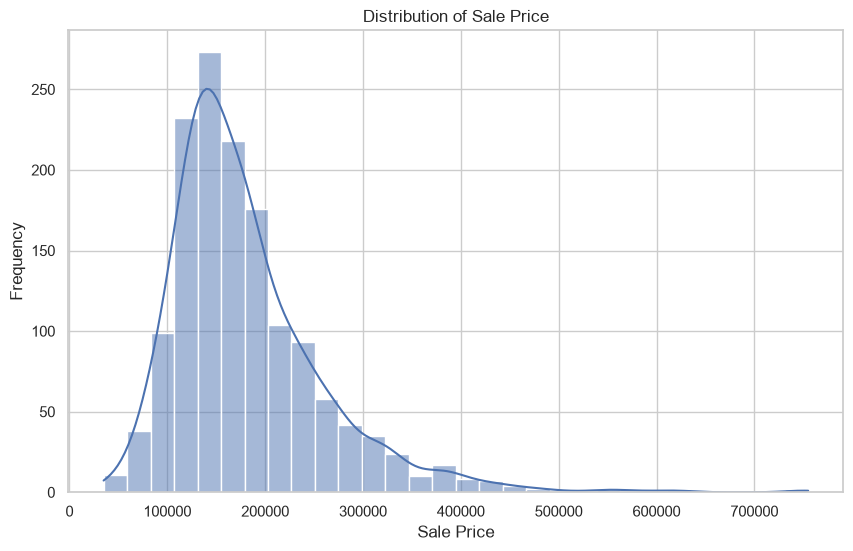

In [5]:
# Distribution Plot

plt.figure(figsize = (10, 6))

sns.histplot(
    train_df["SalePrice"], 
    bins = 30,
    kde = True
)

plt.title("Distribution of Sale Price")
plt.xlabel("Sale Price")
plt.ylabel("Frequency")

plt.savefig("../reports/figures/saleprice_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

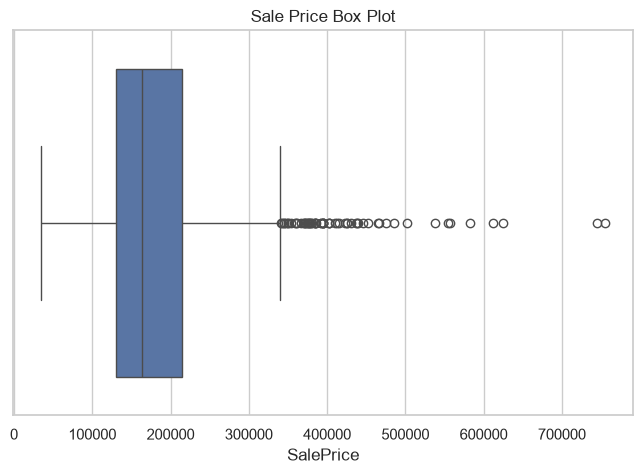

In [6]:
# Box Plot

plt.figure(figsize = (8, 5))

sns.boxplot(
    x = train_df["SalePrice"]
)

plt.title("Sale Price Box Plot")

plt.savefig("../reports/figures/saleprice_boxplot.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

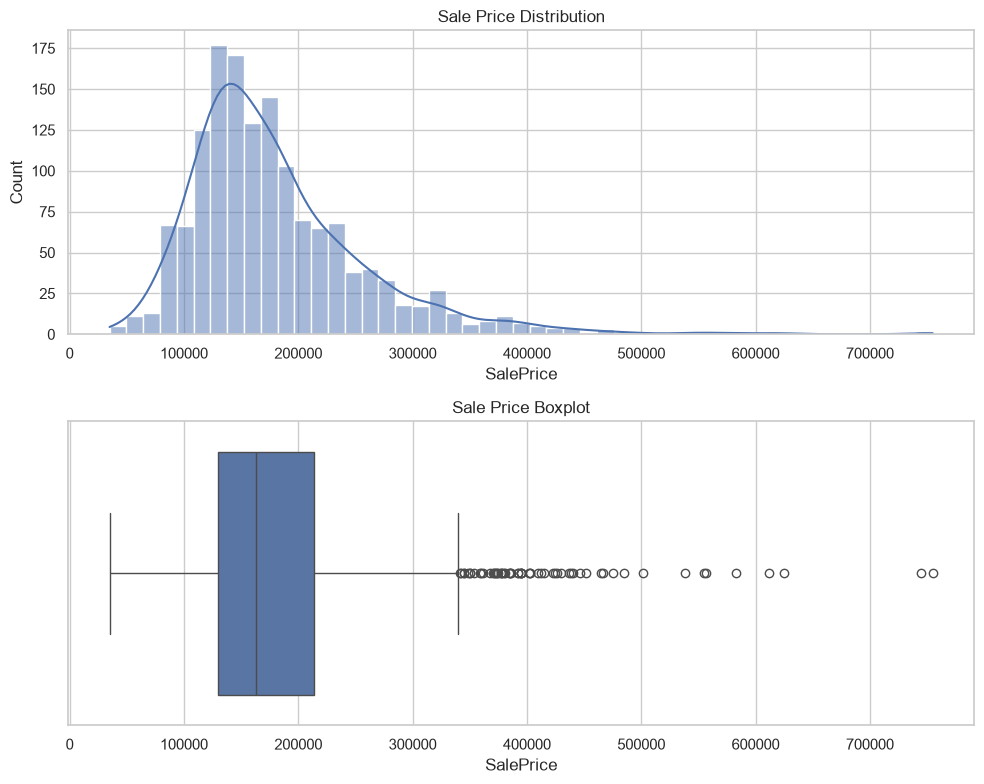

In [7]:
fig, axes = plt.subplots(
    2,
    1,
    figsize=(10,8)
)

sns.histplot(
    train_df["SalePrice"],
    kde=True,
    ax=axes[0]
)

axes[0].set_title("Sale Price Distribution")

sns.boxplot(
    x=train_df["SalePrice"],
    ax=axes[1]
)

axes[1].set_title("Sale Price Boxplot")

plt.tight_layout()

plt.show()

### Observation

- SalePrice is positively skewed.
- A few houses are significantly more expensive than the majority.
- Outliers are clearly visible.
- Log transformation may improve model performance.

In [8]:
numerical_features = train_df.select_dtypes(
    include=["int64","float64"]
).columns

numerical_features

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='str')

In [9]:
important_features = [
    "OverallQual",
    "GrLivArea",
    "GarageArea",
    "TotalBsmtSF",
    "LotArea",
    "YearBuilt"
]

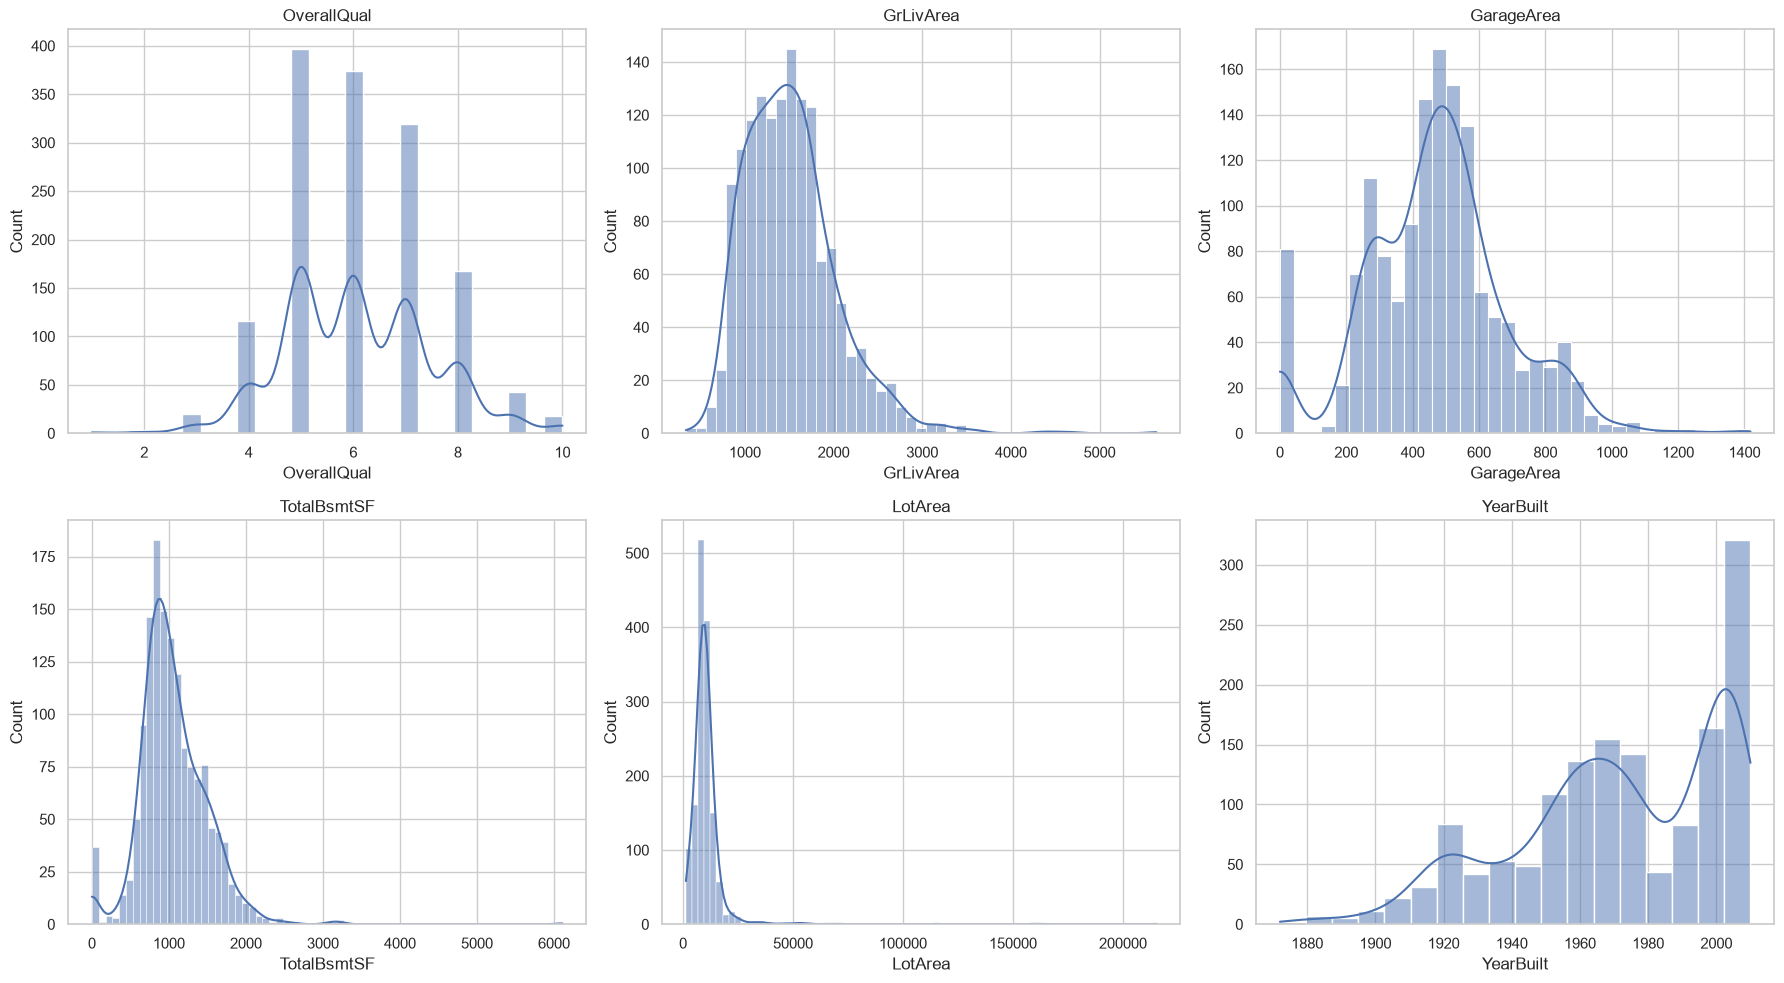

In [10]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(18,10)
)

axes = axes.flatten()

for i, feature in enumerate(important_features):

    sns.histplot(
        train_df[feature],
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(feature)

plt.tight_layout()

plt.savefig("../reports/figures/numerical_feature_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [11]:
categorical_features = train_df.select_dtypes(
    include="object"
).columns

len(categorical_features)

43

In [12]:
top_categorical = [
    "Neighborhood",
    "HouseStyle",
    "KitchenQual"
]

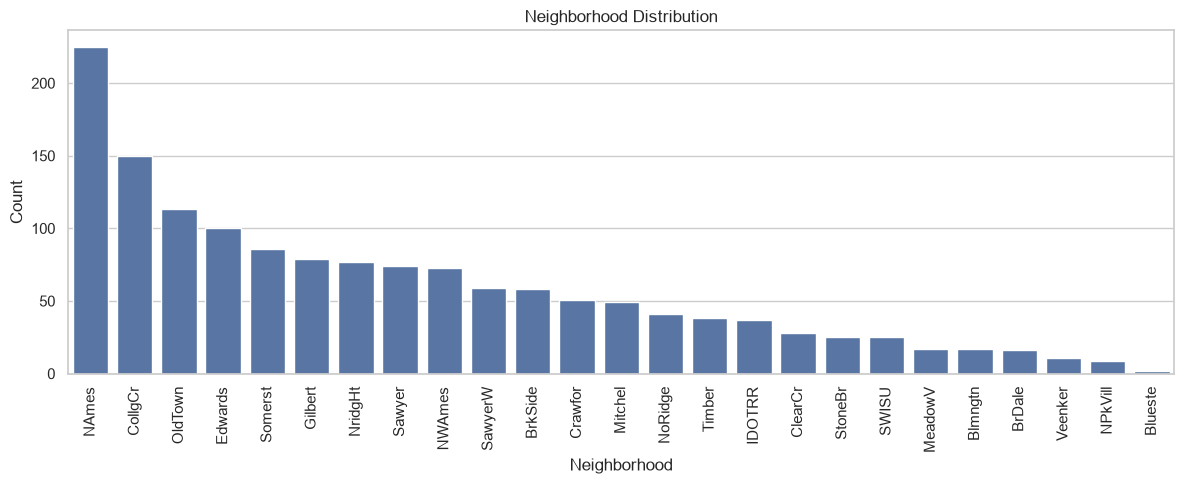

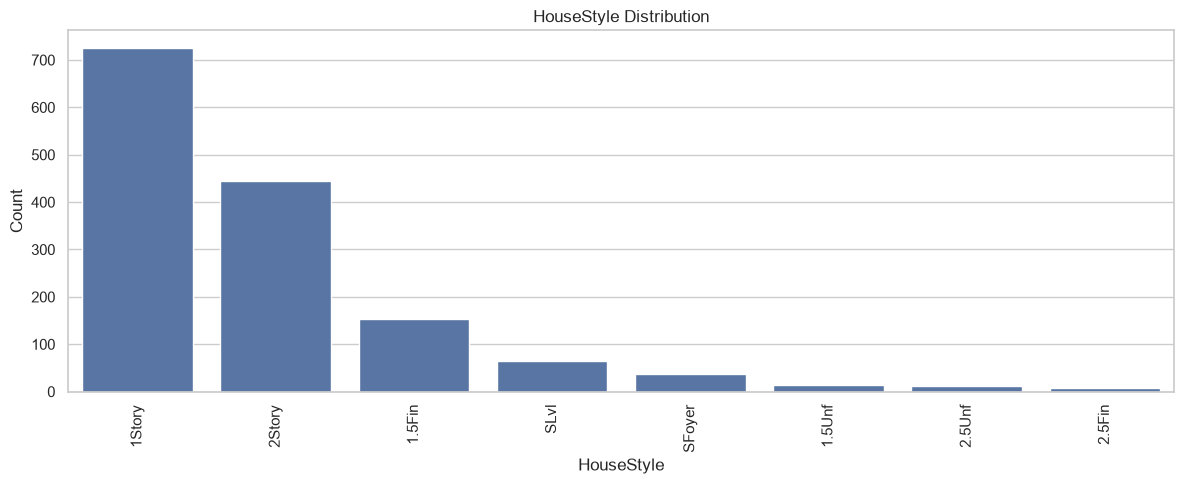

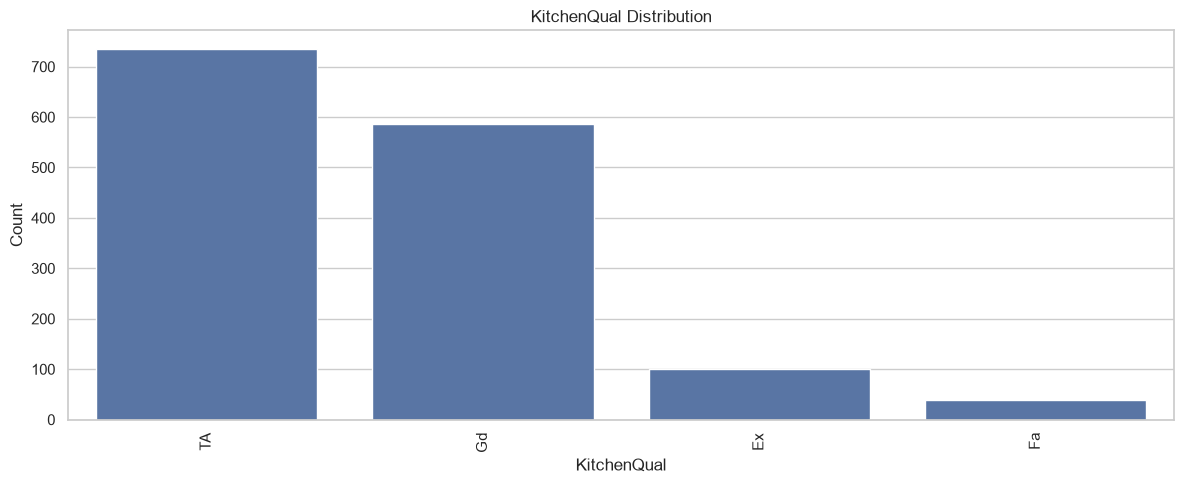

In [13]:
top_categorical = {
    "Neighborhood": "neighborhood_distribution.png",
    "HouseStyle": "house_style_distribution.png",
    "KitchenQual": "kitchen_quality_distribution.png"
}

for feature, filename in top_categorical.items():

    plt.figure(figsize=(12,5))

    sns.countplot(
        data=train_df,
        x=feature,
        order=train_df[feature].value_counts().index
    )

    plt.xticks(rotation=90)

    plt.title(f"{feature} Distribution")
    plt.xlabel(feature)
    plt.ylabel("Count")

    plt.tight_layout()

    plt.savefig(
        f"../reports/figures/{filename}",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()

In [14]:
correlation = train_df.corr(numeric_only = True)

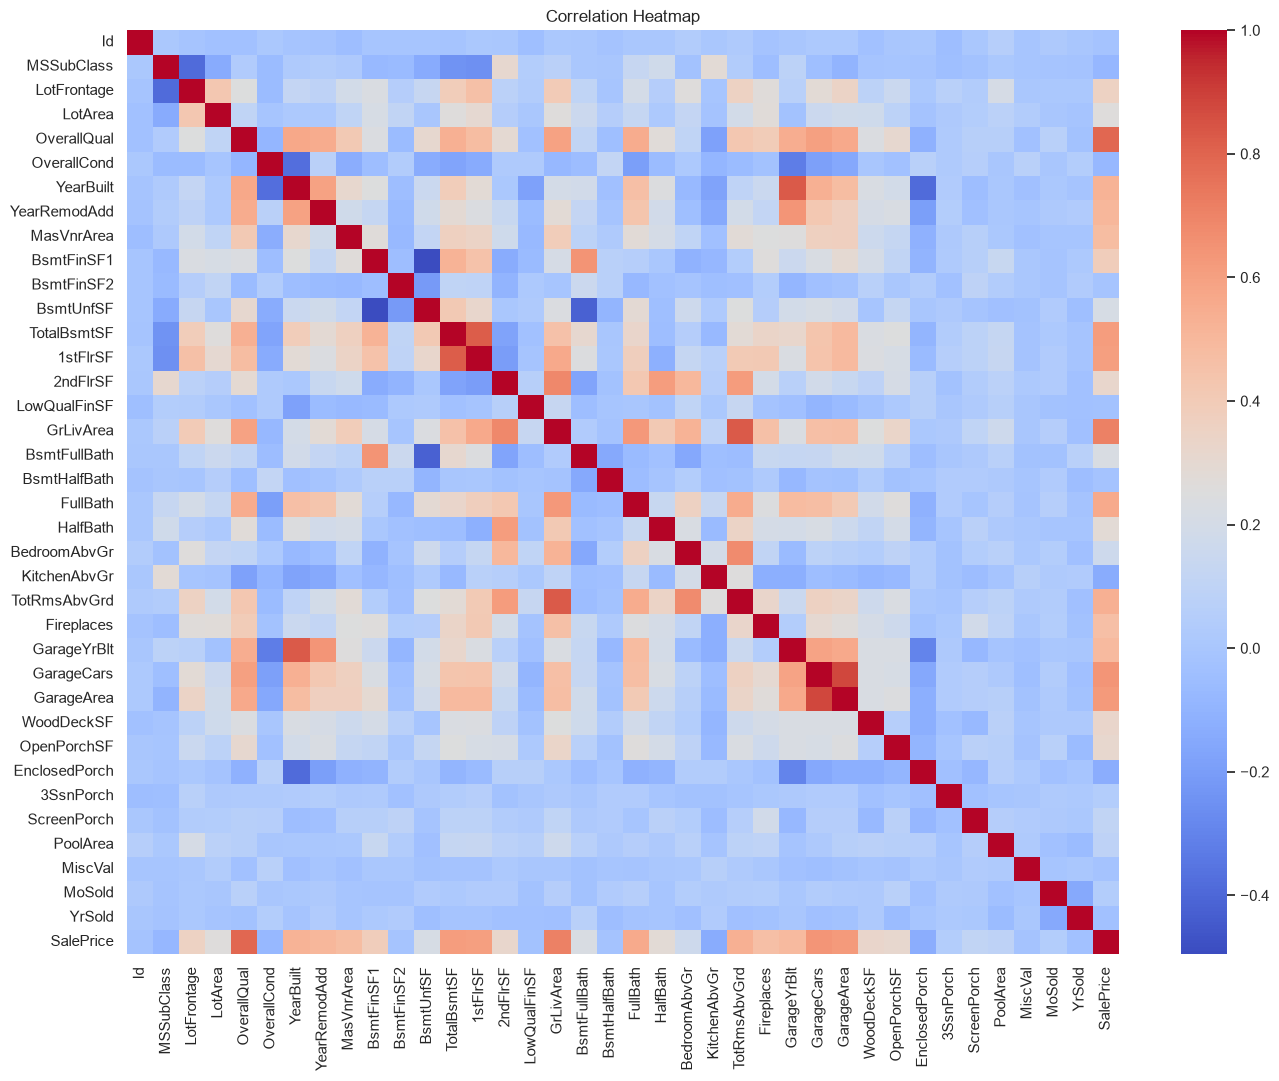

In [15]:
plt.figure(figsize = (16, 12))

sns.heatmap(
    correlation,
    cmap = "coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig("../reports/figures/correlation_heatmap.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [16]:
saleprice_corr = (
    correlation["SalePrice"]
    .sort_values(ascending = False)
)

saleprice_corr.head(15)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64

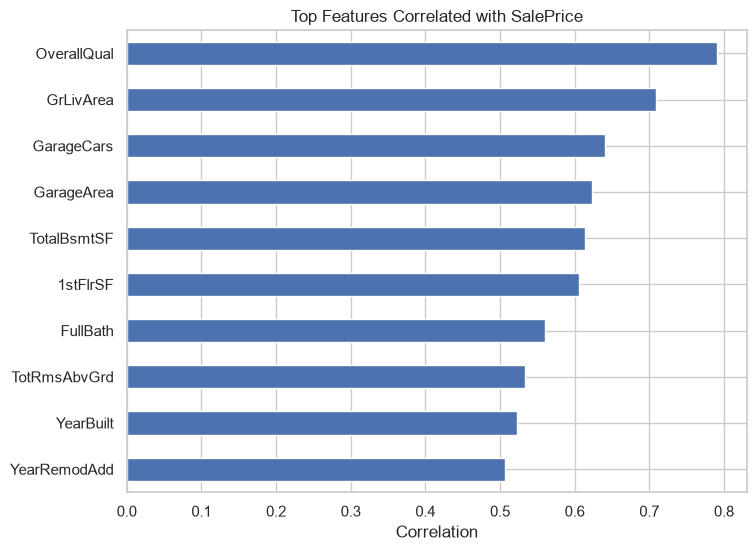

In [17]:
plt.figure(figsize=(8,6))

saleprice_corr[1:11].plot(
    kind="barh"
)

plt.title("Top Features Correlated with SalePrice")

plt.xlabel("Correlation")

plt.gca().invert_yaxis()

plt.savefig("../reports/figures/top_correlated_features.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [18]:
missing = (
    train_df.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing = missing[missing > 0]

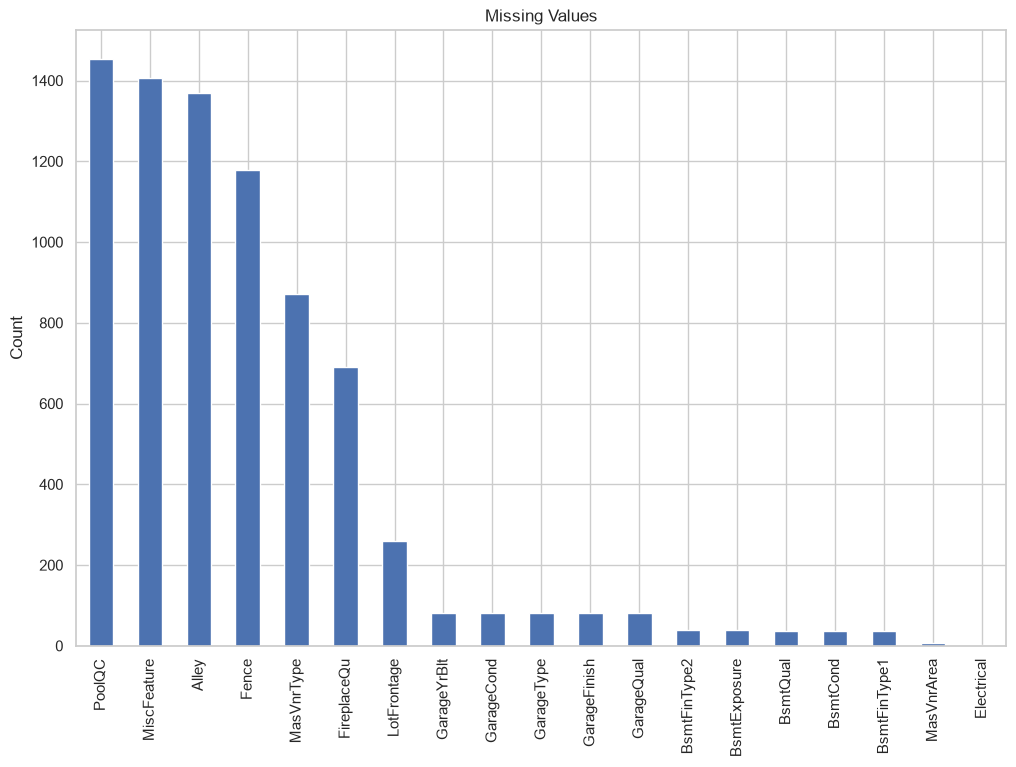

In [19]:
plt.figure(figsize=(12,8))

missing.plot(kind="bar")

plt.title("Missing Values")

plt.ylabel("Count")

plt.savefig("../reports/figures/missing_values.png",
            dpi=300,
            bbox_inches="tight")
        
plt.show()

In [20]:
outlier_features = [
    "GrLivArea",
    "GarageArea",
    "LotArea",
    "SalePrice"
]

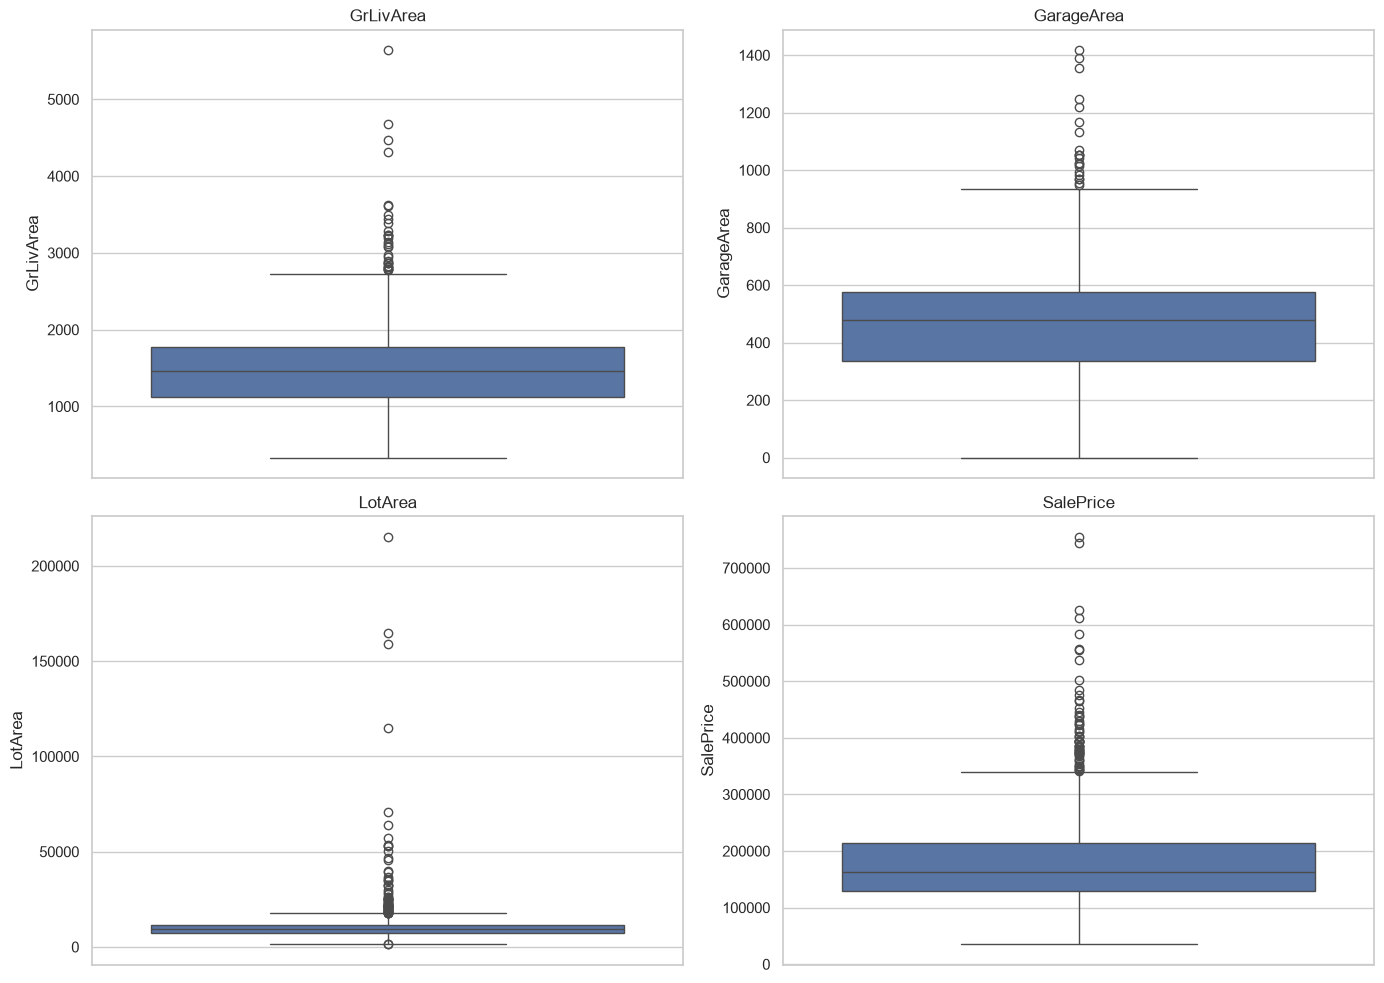

In [21]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(14,10)
)

axes = axes.flatten()

for i, feature in enumerate(outlier_features):

    sns.boxplot(
        y=train_df[feature],
        ax=axes[i]
    )

    axes[i].set_title(feature)

plt.tight_layout()

plt.savefig("../reports/figures/outliers.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [22]:
relationship_features = [
    "OverallQual",
    "GrLivArea",
    "GarageArea",
    "TotalBsmtSF"
]

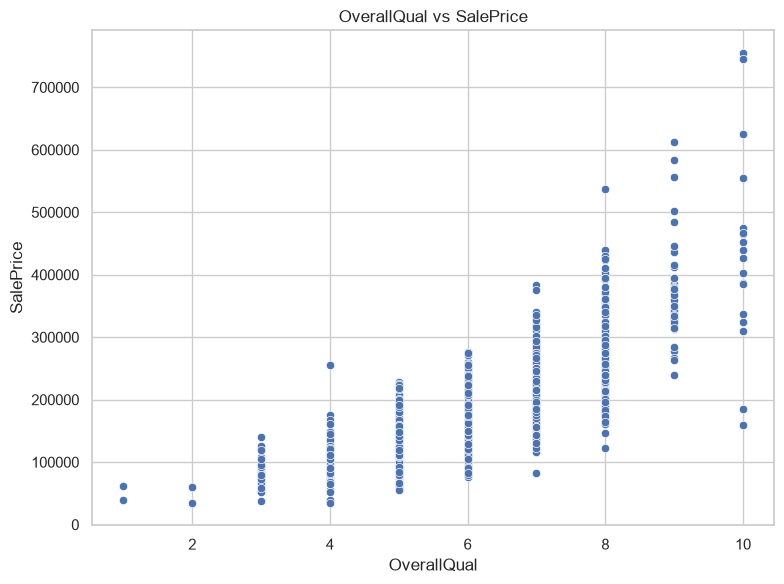

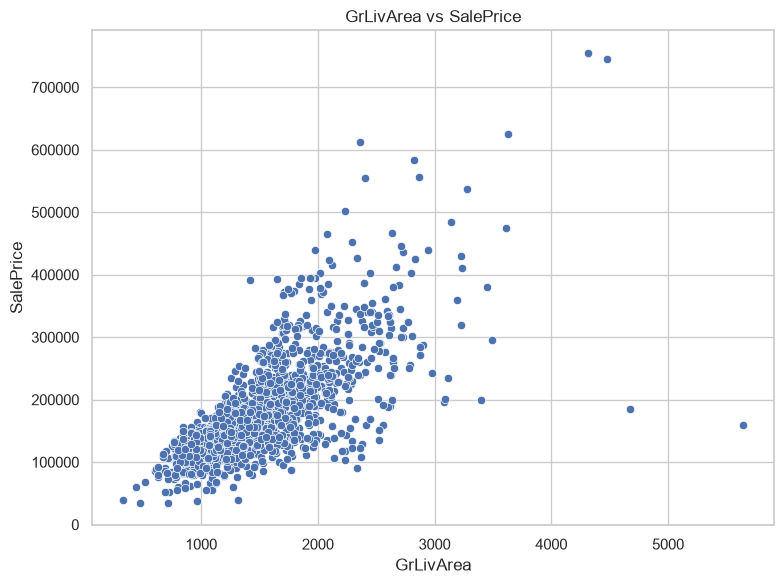

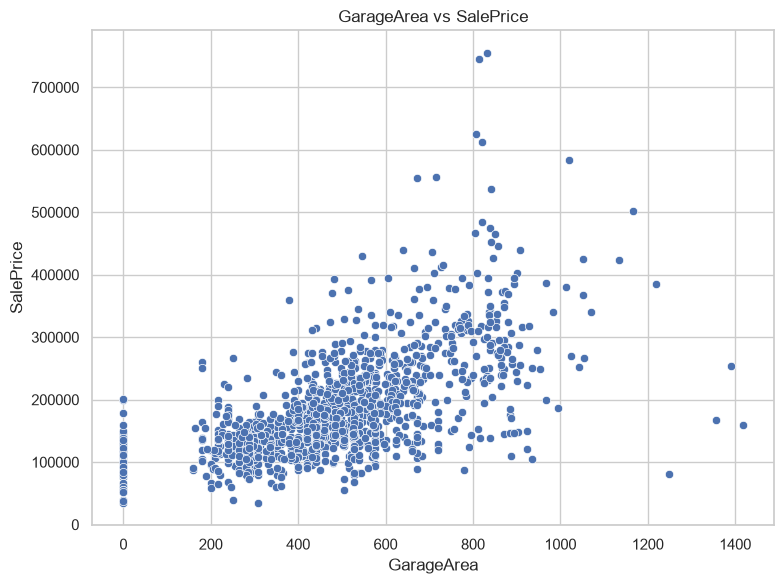

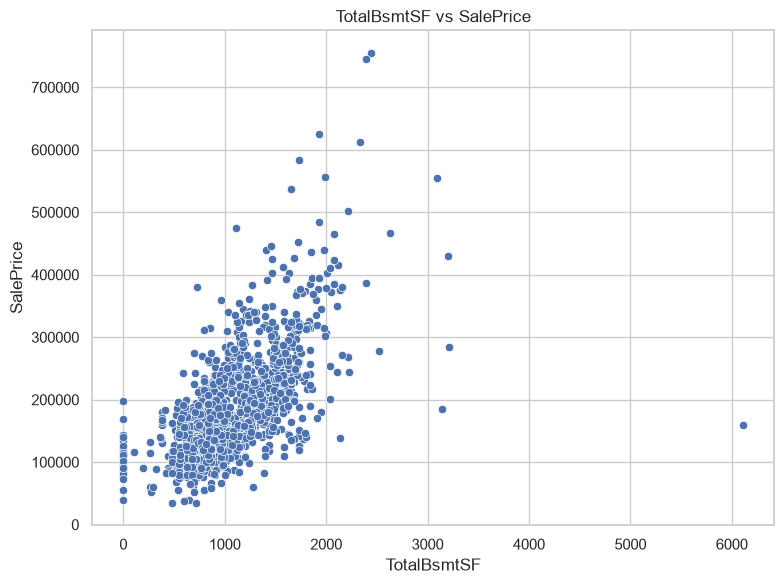

In [23]:
relationship_features = {
    "OverallQual": "overallqual_vs_saleprice.png",
    "GrLivArea": "grlivarea_vs_saleprice.png",
    "GarageArea": "garagearea_vs_saleprice.png",
    "TotalBsmtSF": "totalbsmtsf_vs_saleprice.png"
}

for feature, filename in relationship_features.items():

    plt.figure(figsize=(8,6))

    sns.scatterplot(
        data=train_df,
        x=feature,
        y="SalePrice"
    )

    plt.title(f"{feature} vs SalePrice")
    plt.xlabel(feature)
    plt.ylabel("SalePrice")

    plt.tight_layout()

    plt.savefig(
        f"../reports/figures/{filename}",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

In [24]:
skewness = (
    train_df[numerical_features]
    .skew()
    .sort_values(ascending=False)
)

skewness.head(20)

MiscVal          24.476794
PoolArea         14.828374
LotArea          12.207688
3SsnPorch        10.304342
LowQualFinSF      9.011341
KitchenAbvGr      4.488397
BsmtFinSF2        4.255261
ScreenPorch       4.122214
BsmtHalfBath      4.103403
EnclosedPorch     3.089872
MasVnrArea        2.669084
OpenPorchSF       2.364342
LotFrontage       2.163569
SalePrice         1.882876
BsmtFinSF1        1.685503
WoodDeckSF        1.541376
TotalBsmtSF       1.524255
MSSubClass        1.407657
1stFlrSF          1.376757
GrLivArea         1.366560
dtype: float64

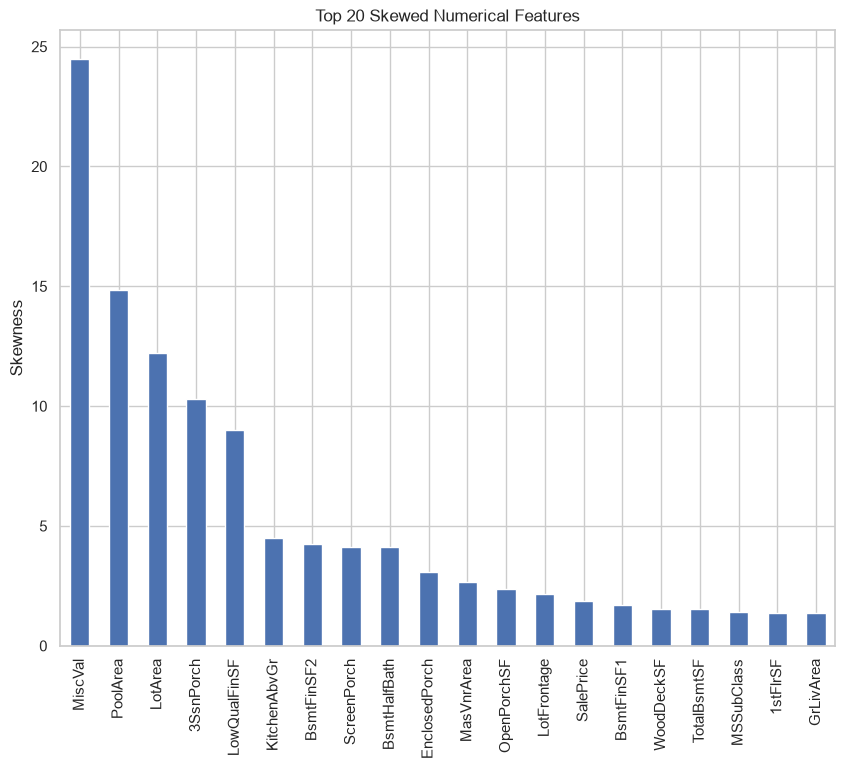

In [25]:
plt.figure(figsize=(10,8))

skewness.head(20).plot(kind="bar")

plt.title("Top 20 Skewed Numerical Features")

plt.ylabel("Skewness")

plt.savefig("../reports/figures/feature_skewness.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

## Key Insights

- SalePrice is positively skewed.
- Several numerical features contain outliers.
- Some categorical variables have many unique categories.
- Several features contain missing values.
- OverallQual and GrLivArea show a strong positive relationship with SalePrice.
- Some numerical features are highly correlated, indicating possible multicollinearity.
- A few features exhibit high skewness and may require transformation during preprocessing.

## Conclusion

This exploratory analysis provided valuable insights into the structure and characteristics of the Ames Housing dataset.

The observations from this notebook will guide the preprocessing phase, including handling missing values, treating outliers, encoding categorical variables, and transforming skewed features before training machine learning models.